# Prediction Analysis -- Experiment 001 vs. Experiment 003

## 1. Objective

**ANALYSIS ONLY.** This notebook analyzes the already-generated test-set
predictions and training histories of experiment 001 (baseline,
validation-selected checkpoint) and experiment 003 (final, all-data,
final-epoch checkpoint) -- both already independently evaluated once on
the identical, untouched 300-image LDCT-IQAC test set (see
`notebooks/04_evaluation/01_test_set_evaluation.ipynb`).

This notebook does **not**:
- retrain, fine-tune, or change any model, checkpoint, or architecture,
- change preprocessing or the dataset,
- rerun the learning-rate search,
- fit any calibration mapping on the test set,
- use test results to tune or select anything.

It reads only:
- `results/predictions/001_resnet50_baseline_test_predictions.csv`
- `results/predictions/003_final_training_test_predictions.csv`
- `experiments/001_resnet50_baseline/history.json`
- `experiments/003_final_training/history.json`

Every finding below is labeled **OBSERVED**, **PLAUSIBLE HYPOTHESIS**, or
**NOT DETERMINED** -- conclusions are never asserted beyond what the
existing data directly supports.

## 2. Existing Experiments (recap, not recomputed)

| | Experiment 001 (baseline) | Experiment 003 (final) |
|---|---|---|
| Training samples | 900 | 1000 (all) |
| Validation samples | 100 | 0 |
| Learning rate | 1e-3 (paper default) | 1e-3 (selected by experiment 002) |
| Epochs | 30 | 30 |
| Checkpoint | best-validation-loss (epoch 21, 0-indexed) | final epoch (epoch 29, 0-indexed) |
| Test PLCC | 0.8804 | 0.8490 |
| Test SROCC | 0.8793 | 0.8525 |
| Test KROCC | 0.6952 | 0.6611 |

Both are Ohashi-style RadImageNet ResNet50 models adapted to LDCT-IQAC --
neither is an exact reproduction of the original paper (different
dataset, different label semantics; see
`docs/replication/dataset_adaptation.md`).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
_repo_root = _cwd if (_cwd / "data").exists() else _cwd.parent.parent  # notebooks/04_evaluation/ -> repo root
import os
os.chdir(_repo_root)
print(f"repo root: {_repo_root}")

pred001 = pd.read_csv("results/predictions/001_resnet50_baseline_test_predictions.csv")
pred003 = pd.read_csv("results/predictions/003_final_training_test_predictions.csv")

assert len(pred001) == 300 and len(pred003) == 300, "expected 300 rows in each prediction file"
assert list(pred001["filename"]) == list(pred003["filename"]), (
    "prediction files must cover the identical, identically-ordered test set for a valid comparison"
)
print(f"loaded {len(pred001)} predictions for experiment 001 and {len(pred003)} for experiment 003")
print("filenames confirmed identical and identically ordered across both prediction files.")

repo root: C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment
loaded 300 predictions for experiment 001 and 300 for experiment 003
filenames confirmed identical and identically ordered across both prediction files.


## 3. Experiment 001 vs. Experiment 003 -- Direct Comparison

Metrics recomputed here from the existing prediction CSVs (not re-run
against the model) purely to build one consistent comparison table --
values must match `results/metrics/001_resnet50_baseline_test_metrics.json`
/ `results/metrics/003_final_training_test_metrics.json` exactly, which is
verified below.

In [2]:
from ct_iqa.evaluation.metrics import compute_metrics

def summarize(pred_df):
    gt = pred_df["ground_truth_score"].to_numpy()
    pred = pred_df["prediction_score"].to_numpy()
    m = compute_metrics(gt, pred)
    mae = float(np.mean(np.abs(pred - gt)))
    rmse = float(np.sqrt(m["mse"]))
    return {"PLCC": m["plcc"], "SROCC": m["srocc"], "KROCC": m["krocc"], "MSE": m["mse"], "MAE": mae, "RMSE": rmse}

metrics001 = summarize(pred001)
metrics003 = summarize(pred003)

# cross-check against the already-persisted metrics JSONs (recomputation must agree, not diverge)
existing001 = json.loads(Path("results/metrics/001_resnet50_baseline_test_metrics.json").read_text())
existing003 = json.loads(Path("results/metrics/003_final_training_test_metrics.json").read_text())
for k, existing_key in [("PLCC", "PLCC"), ("SROCC", "SROCC"), ("KROCC", "KROCC"), ("MSE", "MSE"), ("MAE", "MAE"), ("RMSE", "RMSE")]:
    assert abs(metrics001[k] - existing001["raw"][existing_key]) < 1e-6, f"exp001 {k} mismatch vs persisted metrics"
    assert abs(metrics003[k] - existing003[existing_key]) < 1e-6, f"exp003 {k} mismatch vs persisted metrics"
print("Recomputed metrics match the already-persisted results/metrics/*.json exactly.")

rows = []
for metric in ["PLCC", "SROCC", "KROCC", "MSE", "MAE", "RMSE"]:
    v1, v3 = metrics001[metric], metrics003[metric]
    diff = v3 - v1
    rel_pct = (diff / v1) * 100.0 if v1 != 0 else float("nan")
    rows.append({
        "metric": metric,
        "experiment_001": v1,
        "experiment_003": v3,
        "difference": diff,
        "relative_change_percent": rel_pct,
    })
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

out_path = Path("results/tables/001_vs_003_analysis.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(out_path, index=False)
print(f"saved {out_path}")

Recomputed metrics match the already-persisted results/metrics/*.json exactly.
metric  experiment_001  experiment_003  difference  relative_change_percent
  PLCC        0.880412        0.848953   -0.031459                -3.573212
 SROCC        0.879342        0.852509   -0.026833                -3.051491
 KROCC        0.695180        0.661072   -0.034108                -4.906366
   MSE        0.376484        0.447449    0.070965                18.849402
   MAE        0.502411        0.519472    0.017061                 3.395760
  RMSE        0.613583        0.668916    0.055333                 9.018073
saved results\tables\001_vs_003_analysis.csv


## 4. Prediction Distribution Analysis

Ground-truth and prediction descriptive statistics for both experiments,
on the raw `[0,4]` LDCT-IQAC score scale. `prediction_std / ground_truth_std`
is reported as a simple descriptive ratio only -- **not a formal
calibration metric**.

In [3]:
def describe(arr):
    return {
        "min": float(np.min(arr)), "max": float(np.max(arr)), "mean": float(np.mean(arr)),
        "median": float(np.median(arr)), "std": float(np.std(arr)),
    }

dist_rows = []
for name, df in [("experiment_001", pred001), ("experiment_003", pred003)]:
    gt = df["ground_truth_score"].to_numpy()
    pred = df["prediction_score"].to_numpy()
    gt_stats, pred_stats = describe(gt), describe(pred)
    bias = pred_stats["mean"] - gt_stats["mean"]
    std_ratio = pred_stats["std"] / gt_stats["std"]
    dist_rows.append({
        "experiment": name,
        "gt_min": gt_stats["min"], "gt_max": gt_stats["max"], "gt_mean": gt_stats["mean"],
        "gt_median": gt_stats["median"], "gt_std": gt_stats["std"],
        "pred_min": pred_stats["min"], "pred_max": pred_stats["max"], "pred_mean": pred_stats["mean"],
        "pred_median": pred_stats["median"], "pred_std": pred_stats["std"],
        "bias_pred_minus_gt": bias,
        "prediction_std_over_gt_std": std_ratio,
    })
    print(f"=== {name} ===")
    print(f"  ground truth : min={gt_stats['min']:.3f} max={gt_stats['max']:.3f} mean={gt_stats['mean']:.3f} median={gt_stats['median']:.3f} std={gt_stats['std']:.3f}")
    print(f"  prediction   : min={pred_stats['min']:.3f} max={pred_stats['max']:.3f} mean={pred_stats['mean']:.3f} median={pred_stats['median']:.3f} std={pred_stats['std']:.3f}")
    print(f"  bias (pred_mean - gt_mean)      : {bias:+.4f}")
    print(f"  prediction_std / ground_truth_std (descriptive only, not a calibration metric): {std_ratio:.4f}")
    print()

distribution_df = pd.DataFrame(dist_rows)

=== experiment_001 ===
  ground truth : min=0.000 max=4.000 mean=2.131 median=2.167 std=1.087
  prediction   : min=0.038 max=3.999 mean=2.436 median=2.503 std=1.090
  bias (pred_mean - gt_mean)      : +0.3049
  prediction_std / ground_truth_std (descriptive only, not a calibration metric): 1.0030

=== experiment_003 ===
  ground truth : min=0.000 max=4.000 mean=2.131 median=2.167 std=1.087
  prediction   : min=0.024 max=3.689 mean=1.791 median=1.752 std=0.878
  bias (pred_mean - gt_mean)      : -0.3396
  prediction_std / ground_truth_std (descriptive only, not a calibration metric): 0.8076



## 5. Residual Analysis

`residual = prediction - ground_truth`, `[0,4]` scale, both experiments.
No outlier is removed and no prediction is altered.

In [4]:
def residual_stats(df):
    gt = df["ground_truth_score"].to_numpy()
    pred = df["prediction_score"].to_numpy()
    residuals = pred - gt
    return residuals, {
        "mean": float(residuals.mean()), "median": float(np.median(residuals)),
        "std": float(residuals.std()), "min": float(residuals.min()), "max": float(residuals.max()),
        "MAE": float(np.mean(np.abs(residuals))), "RMSE": float(np.sqrt(np.mean(residuals ** 2))),
    }

residuals001, rstats001 = residual_stats(pred001)
residuals003, rstats003 = residual_stats(pred003)

for name, stats in [("experiment_001", rstats001), ("experiment_003", rstats003)]:
    print(f"=== {name} residuals ===")
    for k, v in stats.items():
        print(f"  {k:<8}: {v:+.4f}" if k != "MAE" and k != "RMSE" else f"  {k:<8}: {v:.4f}")
    print()

=== experiment_001 residuals ===
  mean    : +0.3049
  median  : +0.3503
  std     : +0.5325
  min     : -1.0493
  max     : +1.8586
  MAE     : 0.5024
  RMSE    : 0.6136

=== experiment_003 residuals ===
  mean    : -0.3396
  median  : -0.2732
  std     : +0.5763
  min     : -2.2078
  max     : +1.1197
  MAE     : 0.5195
  RMSE    : 0.6689



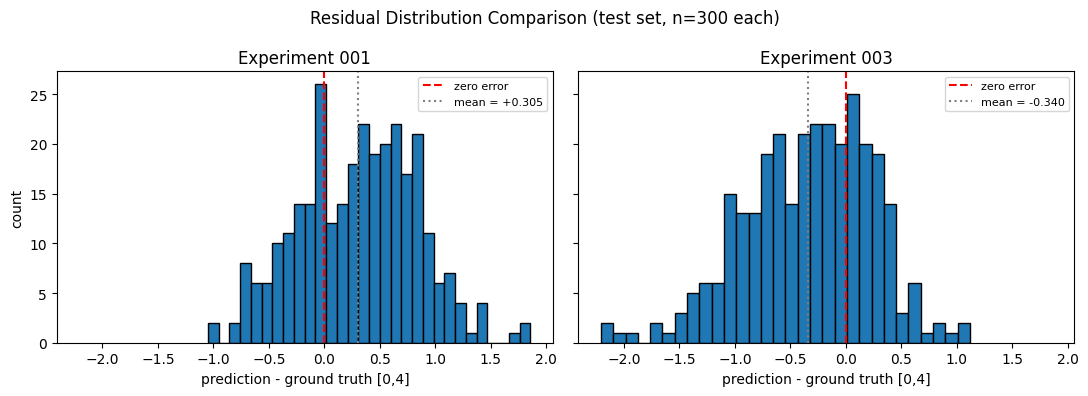

saved results\figures\001_vs_003_residual_comparison.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, name, residuals, stats in [
    (axes[0], "Experiment 001", residuals001, rstats001),
    (axes[1], "Experiment 003", residuals003, rstats003),
]:
    ax.hist(residuals, bins=30, edgecolor="black")
    ax.axvline(0.0, color="red", linestyle="--", label="zero error")
    ax.axvline(stats["mean"], color="gray", linestyle=":", label=f"mean = {stats['mean']:+.3f}")
    ax.set_xlabel("prediction - ground truth [0,4]")
    ax.set_title(name)
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
fig.suptitle("Residual Distribution Comparison (test set, n=300 each)")
plt.tight_layout()
fig_path = Path("results/figures/001_vs_003_residual_comparison.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

## 6. Quality-Bin Analysis

The test set is split into **quartile bins of the ground-truth score
distribution** (`[0,4]` scale) -- a simple, reproducible binning. Computed
independently for both experiments; bins are never used to modify either
model.

In [6]:
def quality_bin_table(df, experiment_name):
    gt = df["ground_truth_score"].to_numpy()
    pred = df["prediction_score"].to_numpy()
    edges = np.quantile(gt, [0.0, 0.25, 0.5, 0.75, 1.0])
    edges[0] -= 1e-6  # include the minimum in the first bin
    bin_idx = np.digitize(gt, edges[1:-1], right=True)
    rows = []
    for b in range(4):
        mask = bin_idx == b
        if mask.sum() == 0:
            continue
        residual = pred[mask] - gt[mask]
        rows.append({
            "experiment": experiment_name,
            "quartile": b + 1,
            "gt_range_low": float(edges[b]),
            "gt_range_high": float(edges[b + 1]),
            "n_samples": int(mask.sum()),
            "mean_ground_truth": float(gt[mask].mean()),
            "mean_prediction": float(pred[mask].mean()),
            "mean_residual": float(residual.mean()),
            "MAE": float(np.mean(np.abs(residual))),
            "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        })
    return rows

bin_rows = quality_bin_table(pred001, "experiment_001") + quality_bin_table(pred003, "experiment_003")
quality_bin_df = pd.DataFrame(bin_rows)
print(quality_bin_df.to_string(index=False))

out_path = Path("results/tables/quality_bin_error_analysis.csv")
quality_bin_df.to_csv(out_path, index=False)
print(f"saved {out_path}")

    experiment  quartile  gt_range_low  gt_range_high  n_samples  mean_ground_truth  mean_prediction  mean_residual      MAE     RMSE
experiment_001         1     -0.000001       1.166667         82           0.774390         1.219782       0.445392 0.544466 0.659069
experiment_001         2      1.166667       2.166667         76           1.756579         2.062040       0.305461 0.559672 0.680397
experiment_001         3      2.166667       3.000000         77           2.705628         3.108715       0.403088 0.552401 0.629200
experiment_001         4      3.000000       4.000000         65           3.600000         3.610468       0.010468 0.323189 0.423532
experiment_003         1     -0.000001       1.166667         82           0.774390         0.882274       0.107884 0.314847 0.385250
experiment_003         2      1.166667       2.166667         76           1.756579         1.452281      -0.304298 0.484847 0.584364
experiment_003         3      2.166667       3.000000         

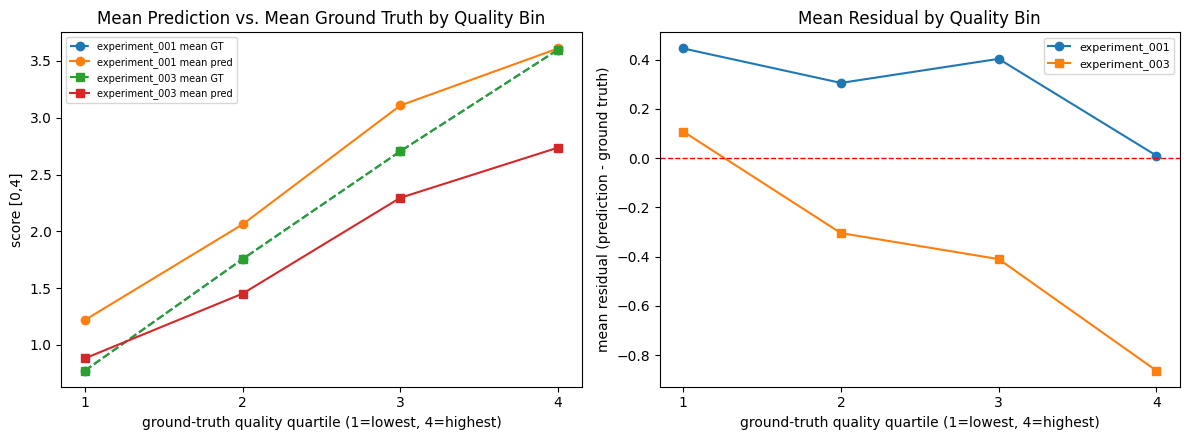

saved results\figures\quality_bin_error_analysis.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, marker in [("experiment_001", "o"), ("experiment_003", "s")]:
    sub = quality_bin_df[quality_bin_df["experiment"] == name]
    axes[0].plot(sub["quartile"], sub["mean_ground_truth"], marker=marker, linestyle="--", label=f"{name} mean GT")
    axes[0].plot(sub["quartile"], sub["mean_prediction"], marker=marker, linestyle="-", label=f"{name} mean pred")
    axes[1].plot(sub["quartile"], sub["mean_residual"], marker=marker, label=name)
axes[0].set_xlabel("ground-truth quality quartile (1=lowest, 4=highest)")
axes[0].set_ylabel("score [0,4]")
axes[0].set_title("Mean Prediction vs. Mean Ground Truth by Quality Bin")
axes[0].set_xticks([1, 2, 3, 4])
axes[0].legend(fontsize=7)

axes[1].axhline(0.0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("ground-truth quality quartile (1=lowest, 4=highest)")
axes[1].set_ylabel("mean residual (prediction - ground truth)")
axes[1].set_title("Mean Residual by Quality Bin")
axes[1].set_xticks([1, 2, 3, 4])
axes[1].legend(fontsize=8)
plt.tight_layout()
fig_path = Path("results/figures/quality_bin_error_analysis.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

## 7. Score Compression Check

Compares `std(prediction)` against `std(ground_truth)` for both
experiments, and fits a **DESCRIPTIVE ANALYSIS ONLY** linear regression
`prediction = a * ground_truth + b` -- this is never used to recalibrate
either model or to generate a final performance metric; it exists only to
describe the shape of the prediction-vs-ground-truth relationship.

In [8]:
from numpy.polynomial import polynomial as P

compression_rows = []
for name, df in [("experiment_001", pred001), ("experiment_003", pred003)]:
    gt = df["ground_truth_score"].to_numpy()
    pred = df["prediction_score"].to_numpy()
    std_ratio = pred.std() / gt.std()

    # DESCRIPTIVE ANALYSIS ONLY -- not used to recalibrate the model or to generate final metrics.
    slope, intercept = np.polyfit(gt, pred, 1)
    pred_fit = slope * gt + intercept
    ss_res = np.sum((pred - pred_fit) ** 2)
    ss_tot = np.sum((pred - pred.mean()) ** 2)
    r_squared = 1 - ss_res / ss_tot

    compression_rows.append({
        "experiment": name,
        "std_prediction": float(pred.std()),
        "std_ground_truth": float(gt.std()),
        "std_ratio_pred_over_gt": float(std_ratio),
        "descriptive_regression_slope": float(slope),
        "descriptive_regression_intercept": float(intercept),
        "descriptive_regression_r_squared": float(r_squared),
    })
    print(f"=== {name} (DESCRIPTIVE ANALYSIS ONLY) ===")
    print(f"  std(prediction)              : {pred.std():.4f}")
    print(f"  std(ground_truth)            : {gt.std():.4f}")
    print(f"  std ratio (pred/gt)          : {std_ratio:.4f}  (< 1.0 suggests some narrowing toward the mean)")
    print(f"  descriptive fit: prediction = {slope:.4f} * ground_truth + {intercept:.4f}   (R^2 = {r_squared:.4f})")
    print(f"  (an ideal, uncompressed 1:1 relationship would have slope=1.0, intercept=0.0)")
    print()

compression_df = pd.DataFrame(compression_rows)
print("DESCRIPTIVE ANALYSIS ONLY -- not used to recalibrate either model or to generate final performance metrics.")

=== experiment_001 (DESCRIPTIVE ANALYSIS ONLY) ===
  std(prediction)              : 1.0905
  std(ground_truth)            : 1.0871
  std ratio (pred/gt)          : 1.0030  (< 1.0 suggests some narrowing toward the mean)
  descriptive fit: prediction = 0.8831 * ground_truth + 0.5540   (R^2 = 0.7751)
  (an ideal, uncompressed 1:1 relationship would have slope=1.0, intercept=0.0)

=== experiment_003 (DESCRIPTIVE ANALYSIS ONLY) ===
  std(prediction)              : 0.8780
  std(ground_truth)            : 1.0871
  std ratio (pred/gt)          : 0.8076  (< 1.0 suggests some narrowing toward the mean)
  descriptive fit: prediction = 0.6856 * ground_truth + 0.3303   (R^2 = 0.7207)
  (an ideal, uncompressed 1:1 relationship would have slope=1.0, intercept=0.0)

DESCRIPTIVE ANALYSIS ONLY -- not used to recalibrate either model or to generate final performance metrics.


## 8. Predicted vs. Ground-Truth Scatter (identity line vs. descriptive regression line)

Distinct from the evaluation notebook's own pred-vs-gt figures
(`results/figures/00{1,3}_*_test_pred_vs_gt.png`, not overwritten here) --
these versions additionally overlay the **descriptive-only** regression
line from Section 7, clearly distinguished from the identity line.

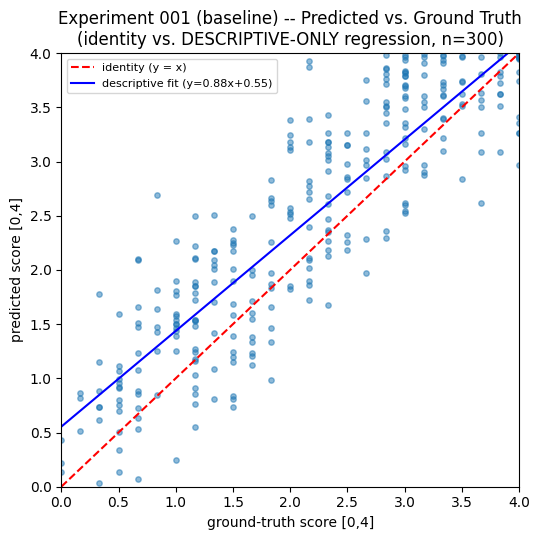

saved results\figures\001_prediction_vs_gt_analysis.png


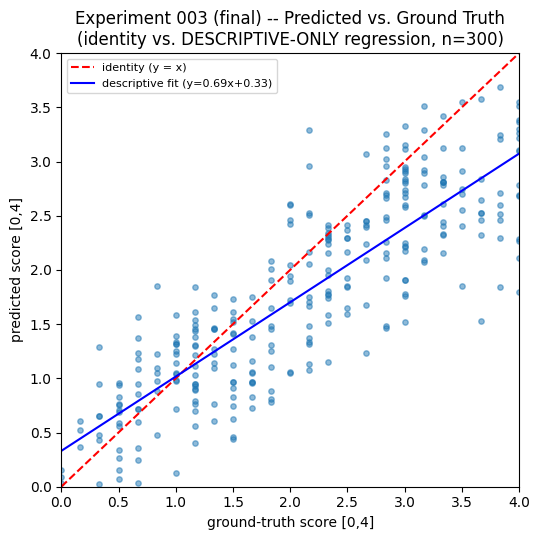

saved results\figures\003_prediction_vs_gt_analysis.png


In [9]:
from ct_iqa.data.ldct_iqac import SCORE_MIN, SCORE_MAX

for name, df, comp_row, out_name in [
    ("Experiment 001 (baseline)", pred001, compression_rows[0], "001_prediction_vs_gt_analysis.png"),
    ("Experiment 003 (final)", pred003, compression_rows[1], "003_prediction_vs_gt_analysis.png"),
]:
    gt = df["ground_truth_score"].to_numpy()
    pred = df["prediction_score"].to_numpy()
    slope, intercept = comp_row["descriptive_regression_slope"], comp_row["descriptive_regression_intercept"]

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(gt, pred, alpha=0.5, s=15)
    ax.plot([SCORE_MIN, SCORE_MAX], [SCORE_MIN, SCORE_MAX], "r--", label="identity (y = x)")
    x_line = np.array([SCORE_MIN, SCORE_MAX])
    ax.plot(x_line, slope * x_line + intercept, "b-", label=f"descriptive fit (y={slope:.2f}x+{intercept:.2f})")
    ax.set_xlabel("ground-truth score [0,4]")
    ax.set_ylabel("predicted score [0,4]")
    ax.set_xlim(SCORE_MIN, SCORE_MAX)
    ax.set_ylim(SCORE_MIN, SCORE_MAX)
    ax.legend(fontsize=8)
    ax.set_title(f"{name} -- Predicted vs. Ground Truth\n(identity vs. DESCRIPTIVE-ONLY regression, n={len(df)})")
    plt.tight_layout()
    fig_path = Path(f"results/figures/{out_name}")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {fig_path}")

## 9. Error vs. Quality

Absolute error (`|prediction - ground_truth|`) plotted against
ground-truth score, for both experiments. Any low-quality-vs-high-quality
error-magnitude pattern is described as an **observed relationship**, with
no causal claim.

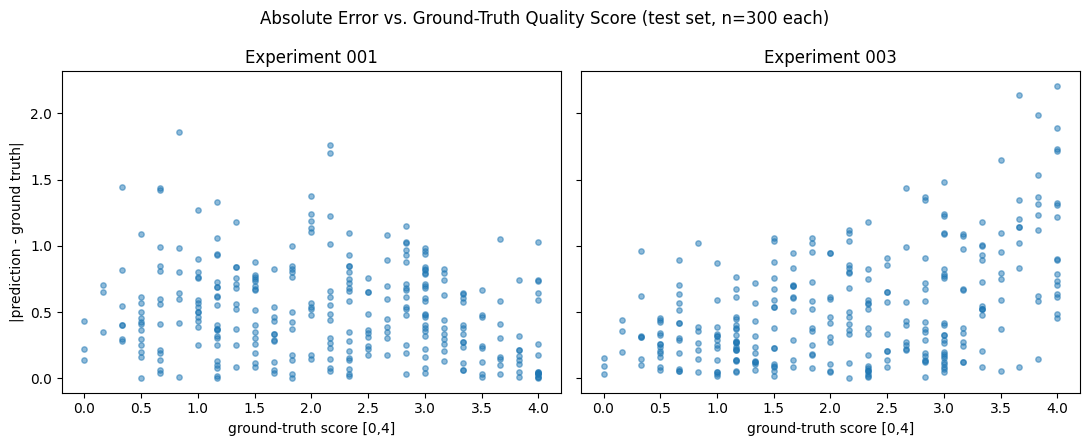

saved results\figures\001_vs_003_error_vs_quality.png

Experiment 001: corr(ground_truth, |error|) = -0.171  | mean |error| in lowest GT quartile = 0.544  | mean |error| in highest GT quartile = 0.389
Experiment 003: corr(ground_truth, |error|) = +0.462  | mean |error| in lowest GT quartile = 0.315  | mean |error| in highest GT quartile = 0.783

Reported as an OBSERVED relationship (if present), not a causal claim.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
error_vs_quality_summary = []
for ax, name, df in [(axes[0], "Experiment 001", pred001), (axes[1], "Experiment 003", pred003)]:
    gt = df["ground_truth_score"].to_numpy()
    pred = df["prediction_score"].to_numpy()
    abs_err = np.abs(pred - gt)
    ax.scatter(gt, abs_err, alpha=0.5, s=15)
    ax.set_xlabel("ground-truth score [0,4]")
    ax.set_title(name)

    # simple descriptive correlation between |ground truth| position and |error| -- observation only.
    corr = float(np.corrcoef(gt, abs_err)[0, 1])
    low_mask = gt <= np.quantile(gt, 0.25)
    high_mask = gt >= np.quantile(gt, 0.75)
    error_vs_quality_summary.append({
        "experiment": name,
        "corr_gt_vs_abs_error": corr,
        "mean_abs_error_low_quartile": float(abs_err[low_mask].mean()),
        "mean_abs_error_high_quartile": float(abs_err[high_mask].mean()),
    })
axes[0].set_ylabel("|prediction - ground truth|")
fig.suptitle("Absolute Error vs. Ground-Truth Quality Score (test set, n=300 each)")
plt.tight_layout()
fig_path = Path("results/figures/001_vs_003_error_vs_quality.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")
print()
for row in error_vs_quality_summary:
    print(f"{row['experiment']}: corr(ground_truth, |error|) = {row['corr_gt_vs_abs_error']:+.3f}  "
          f"| mean |error| in lowest GT quartile = {row['mean_abs_error_low_quartile']:.3f}  "
          f"| mean |error| in highest GT quartile = {row['mean_abs_error_high_quartile']:.3f}")
print()
print("Reported as an OBSERVED relationship (if present), not a causal claim.")

## 10. Training-Curve Analysis

Experiment 001 has both `train_loss` and `val_loss` (100-image validation
split); experiment 003 has only `train_loss` (no validation split exists
for it -- **no validation behavior is fabricated for experiment 003
below**).

In [11]:
history001 = json.loads(Path("experiments/001_resnet50_baseline/history.json").read_text())
history003 = json.loads(Path("experiments/003_final_training/history.json").read_text())

best_epoch = history001["best_epoch"]
train_at_best = history001["train_loss"][best_epoch]
val_at_best = history001["val_loss"][best_epoch]
print("=== Experiment 001 (has a validation split) ===")
print(f"  best epoch (0-indexed)       : {best_epoch}")
print(f"  train loss at best epoch     : {train_at_best:.6f}")
print(f"  val loss at best epoch       : {val_at_best:.6f}")
print(f"  final (epoch 30) train loss  : {history001['final_train_loss']:.6f}")
print(f"  final (epoch 30) val loss    : {history001['final_val_loss']:.6f}")

late_val = history001["val_loss"][best_epoch + 1 :]
degraded_after_best = any(v > val_at_best for v in late_val)
print(f"  any post-best-epoch val_loss exceeds the best val_loss: {degraded_after_best}")
print(f"  (this is the noisy small-validation-split behavior already documented in")
print(f"   experiments/001_resnet50_baseline/README.md -- val_loss spikes to "
      f"{max(late_val):.4f} at a later epoch, then does not stay elevated every epoch after)")

print()
print("=== Experiment 003 (NO validation split -- val_loss not recorded, not fabricated here) ===")
print(f"  final (epoch 30) train loss  : {history003['final_train_loss']:.6f}")
print(f"  train loss trajectory        : starts {history003['train_loss'][0]:.6f}, ends {history003['train_loss'][-1]:.6f}")
print(f"  note in history.json         : {history003['note']!r}")

=== Experiment 001 (has a validation split) ===
  best epoch (0-indexed)       : 21
  train loss at best epoch     : 0.002521
  val loss at best epoch       : 0.003052
  final (epoch 30) train loss  : 0.003255
  final (epoch 30) val loss    : 0.018703
  any post-best-epoch val_loss exceeds the best val_loss: True
  (this is the noisy small-validation-split behavior already documented in
   experiments/001_resnet50_baseline/README.md -- val_loss spikes to 0.1074 at a later epoch, then does not stay elevated every epoch after)

=== Experiment 003 (NO validation split -- val_loss not recorded, not fabricated here) ===
  final (epoch 30) train loss  : 0.001783
  train loss trajectory        : starts 0.023430, ends 0.001783
  note in history.json         : 'No validation split in this run -- no val_loss recorded, no best-epoch selection performed.'


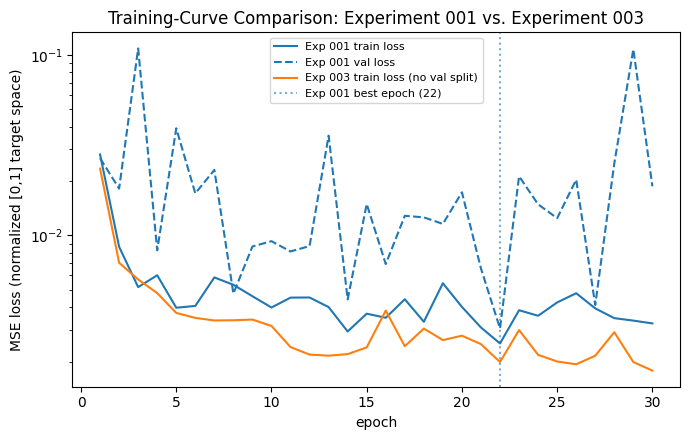

saved results\figures\001_vs_003_training_curves.png

IMPORTANT: experiment 003's test-set underperformance is NOT concluded to be 'overfitting'
from this curve alone -- experiment 003 has no validation signal to demonstrate overfitting
against. Its final training loss (0.001783) is in fact LOWER than experiment 001's final
training loss (0.003255), which is consistent with (but does not prove) several different
explanations -- see Section 11/13 below.


In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
epochs001 = np.arange(1, len(history001["train_loss"]) + 1)
epochs003 = np.arange(1, len(history003["train_loss"]) + 1)
ax.plot(epochs001, history001["train_loss"], label="Exp 001 train loss", color="tab:blue")
ax.plot(epochs001, history001["val_loss"], label="Exp 001 val loss", color="tab:blue", linestyle="--")
ax.plot(epochs003, history003["train_loss"], label="Exp 003 train loss (no val split)", color="tab:orange")
ax.axvline(best_epoch + 1, color="tab:blue", linestyle=":", alpha=0.6, label=f"Exp 001 best epoch ({best_epoch + 1})")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss (normalized [0,1] target space)")
ax.set_yscale("log")
ax.set_title("Training-Curve Comparison: Experiment 001 vs. Experiment 003")
ax.legend(fontsize=8)
plt.tight_layout()
fig_path = Path("results/figures/001_vs_003_training_curves.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")
print()
print("IMPORTANT: experiment 003's test-set underperformance is NOT concluded to be 'overfitting'")
print("from this curve alone -- experiment 003 has no validation signal to demonstrate overfitting")
print("against. Its final training loss (0.001783) is in fact LOWER than experiment 001's final")
print("training loss (0.003255), which is consistent with (but does not prove) several different")
print("explanations -- see Section 11/13 below.")

## 11. Investigating the Experiment 001 vs. Experiment 003 Difference

**OBSERVED** (directly measured, not inferred):

- Experiment 001 test PLCC/SROCC/KROCC are each higher than experiment
  003's (Section 3).
- Experiment 001's prediction bias is **+0.305** (overprediction);
  experiment 003's is **-0.3396** (underprediction) -- the sign flipped.
- Experiment 003's *final training loss* (0.001783) is lower than
  experiment 001's *final training loss* (0.003255) -- i.e. experiment 003
  fits its own (larger, 1000-image) training set at least as tightly as
  experiment 001 fits its (900-image) training set, by the training-loss
  metric alone.
- Experiment 001's checkpoint was selected by lowest **validation** loss
  (epoch 21 of 30); experiment 003's checkpoint has no such selection --
  it is unconditionally the epoch-30 (final) model.
- Experiment 003 was trained on all 1000 labeled images; experiment 001
  was trained on 900 of the 1000 (100 held out for validation).

**PLAUSIBLE HYPOTHESIS** (consistent with the observed evidence, but not
proven by it):

- Experiment 001's validation-based checkpoint selection may have acted as
  an implicit form of early stopping/regularization, favoring a
  checkpoint with better generalization at the cost of further in-sample
  fit -- while experiment 003's unconditional final-epoch checkpoint had
  no such selection pressure applied.
- The bias-sign flip (+0.305 vs. -0.3396) could reflect a difference in
  where each specific checkpoint's Sigmoid output happened to sit at the
  moment it was selected/stopped, rather than a property of "all-data
  training" as such.
- Using all 1000 training images (vs. 900) removing the held-out 100 could
  plausibly change the effective training distribution seen late in
  training, but this project's data has not been inspected further to
  confirm or rule this out.

**NOT DETERMINED** (the existing data does not resolve this):

- Whether checkpoint selection (validation-based vs. final-epoch),
  training-set size (900 vs. 1000), or some combination is the dominant
  cause of the performance gap -- no controlled ablation (e.g. a
  final-epoch checkpoint from a 900/100-split run, or a validation-based
  checkpoint from an all-1000 run) exists in this project to isolate these
  factors.
- Whether experiment 003's final-epoch checkpoint is actually worse than
  an earlier epoch of the *same* training run would have been -- no
  validation signal exists for experiment 003 to check this, and
  evaluating intermediate experiment-003 checkpoints against the test set
  would itself contaminate the test set and is explicitly out of scope for
  this analysis phase.
- Any causal mechanism for the bias-sign flip specifically -- both
  directions are plausible outcomes of an uncalibrated Sigmoid regression
  head, and this project's data does not distinguish between the
  hypotheses above.

## 12. Calibration Analysis (no fitting performed here)

`src/ct_iqa/evaluation/calibration.py` implements a standard
five-parameter logistic (5PL) fit
(`five_parameter_logistic_fit(y_pred, y_true)`), used elsewhere in this
project's evaluation methodology (`docs/paper/evaluation.md`). It fits its
5 parameters directly against whatever `(y_pred, y_true)` pair it
receives via `scipy.optimize.curve_fit` -- there is no built-in
train/apply split.

**No calibration mapping is fit on the test set in this notebook** (or
anywhere in this project to date). The test-set metrics already reported
(Section 3) remain unchanged.

In [13]:
print("Is a valid calibration experiment constructible from training/validation data only,")
print("without touching the test set?")
print()
print("- Experiment 001 has a 100-image validation split with recorded predictions available")
print("  in principle (via its training-time validation_metrics.json), but no PER-IMAGE validation")
print("  prediction CSV currently exists in results/ -- only the final validation summary metrics")
print("  (MSE/PLCC/SROCC/KROCC) were persisted, not raw (y_pred, y_true) pairs suitable for fitting")
print("  five_parameter_logistic_fit.")
print("- Experiment 003 has NO validation split at all (all 1000 images used for training), so no")
print("  held-out, non-test data exists for it to fit a calibration mapping against.")
print("- No 'fit on validation, apply fixed mapping to test' code path exists anywhere in")
print("  src/ct_iqa/ -- five_parameter_logistic_fit is a bare fit-and-map function with no notion")
print("  of a frozen, reusable mapping object.")
print()
print("CALIBRATION STATUS: requires new protocol")
print()
print("Reasoning: a valid protocol would need (1) per-image validation predictions persisted for")
print("experiment 001 (not currently saved), (2) an explicit 'fit on validation, freeze parameters,")
print("apply unchanged to test' code path (not currently implemented), and (3) a decision about")
print("what (if anything) a comparable protocol would mean for experiment 003, which has no")
print("validation split to fit against. None of this exists yet, and implementing it is a new")
print("protocol decision, not something this analysis-only phase performs.")

Is a valid calibration experiment constructible from training/validation data only,
without touching the test set?

- Experiment 001 has a 100-image validation split with recorded predictions available
  in principle (via its training-time validation_metrics.json), but no PER-IMAGE validation
  prediction CSV currently exists in results/ -- only the final validation summary metrics
  (MSE/PLCC/SROCC/KROCC) were persisted, not raw (y_pred, y_true) pairs suitable for fitting
  five_parameter_logistic_fit.
- Experiment 003 has NO validation split at all (all 1000 images used for training), so no
  held-out, non-test data exists for it to fit a calibration mapping against.
- No 'fit on validation, apply fixed mapping to test' code path exists anywhere in
  src/ct_iqa/ -- five_parameter_logistic_fit is a bare fit-and-map function with no notion
  of a frozen, reusable mapping object.

CALIBRATION STATUS: requires new protocol

Reasoning: a valid protocol would need (1) per-image validation 

## 13. Largest-Error Examples

Top 10 highest-absolute-error test images for each experiment, read
directly from the existing prediction CSVs. Not used for retraining, not
removed from the test set.

In [14]:
def top_error_cases(df, n=10):
    out = df.copy()
    out["residual"] = out["prediction_score"] - out["ground_truth_score"]
    out["absolute_error"] = out["residual"].abs()
    out = out.sort_values("absolute_error", ascending=False).head(n)
    return out[["filename", "ground_truth_score", "prediction_score", "residual", "absolute_error"]].reset_index(drop=True)

top001 = top_error_cases(pred001)
top003 = top_error_cases(pred003)

print("=== Experiment 001 -- top 10 absolute-error cases ===")
print(top001.to_string(index=False))
print()
print("=== Experiment 003 -- top 10 absolute-error cases ===")
print(top003.to_string(index=False))

top001.to_csv("results/tables/001_top_error_cases.csv", index=False)
top003.to_csv("results/tables/003_top_error_cases.csv", index=False)
print()
print("saved results/tables/001_top_error_cases.csv")
print("saved results/tables/003_top_error_cases.csv")

=== Experiment 001 -- top 10 absolute-error cases ===
    filename  ground_truth_score  prediction_score  residual  absolute_error
test235.tiff            0.833333          2.691933  1.858599        1.858599
test006.tiff            2.166667          3.931929  1.765262        1.765262
test248.tiff            2.166667          3.869622  1.702955        1.702955
test228.tiff            0.333333          1.775648  1.442315        1.442315
test236.tiff            0.666667          2.101891  1.435225        1.435225
test145.tiff            0.666667          2.087515  1.420848        1.420848
test238.tiff            2.000000          3.379901  1.379901        1.379901
test091.tiff            1.166667          2.495023  1.328356        1.328356
test267.tiff            1.000000          2.271064  1.271064        1.271064
test185.tiff            2.000000          3.241382  1.241382        1.241382

=== Experiment 003 -- top 10 absolute-error cases ===
    filename  ground_truth_score  prediction

### Qualitative error-analysis figure

Displays the top-4 highest-error test images for each experiment (image +
ground truth + prediction), if the raw test images are available on disk.
No medical/diagnostic claim is made about any image -- only the numeric
model behavior on it is shown.

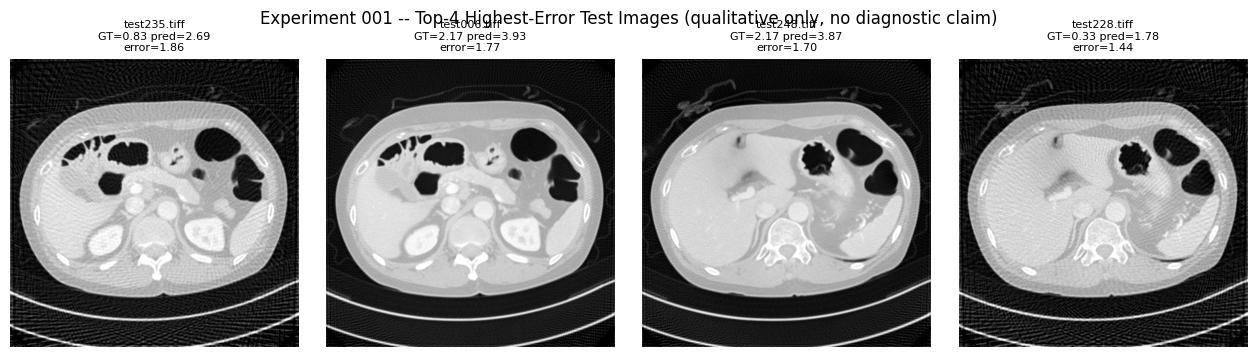

saved results\figures\001_top_error_cases_qualitative.png


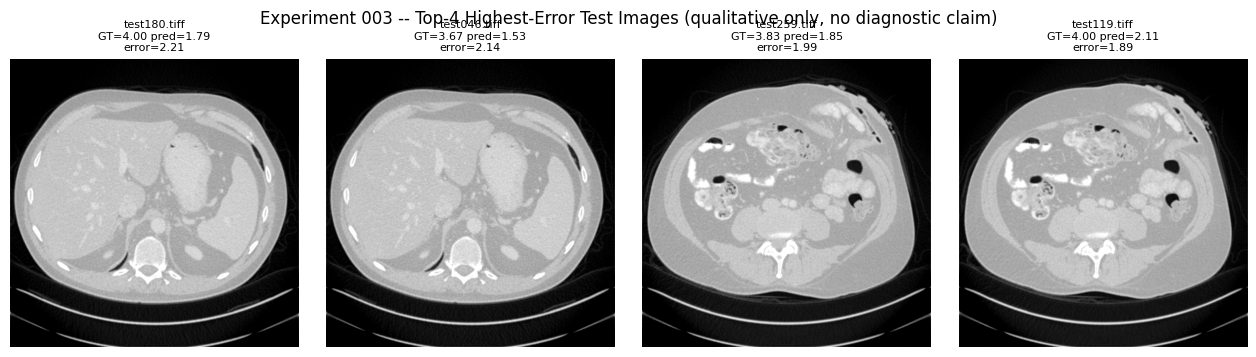

saved results\figures\003_top_error_cases_qualitative.png


In [15]:
import numpy as np
from PIL import Image

test_image_dir = Path("data/raw/ldct_iqac/test/images")

def show_top_errors(top_df, experiment_name, out_name, n=4):
    if not test_image_dir.exists():
        print(f"{test_image_dir} not found locally -- skipping qualitative figure for {experiment_name}.")
        return
    rows = top_df.head(n)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.6))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        img_path = test_image_dir / row["filename"]
        try:
            with Image.open(img_path) as im:
                arr = np.array(im)
        except FileNotFoundError:
            ax.axis("off")
            ax.set_title(f"{row['filename']}\n(image not found)")
            continue
        ax.imshow(arr, cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"{row['filename']}\nGT={row['ground_truth_score']:.2f} pred={row['prediction_score']:.2f}\n"
            f"error={row['absolute_error']:.2f}",
            fontsize=8,
        )
    fig.suptitle(f"{experiment_name} -- Top-{n} Highest-Error Test Images (qualitative only, no diagnostic claim)")
    plt.tight_layout()
    fig_path = Path(f"results/figures/{out_name}")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {fig_path}")

show_top_errors(top001, "Experiment 001", "001_top_error_cases_qualitative.png")
show_top_errors(top003, "Experiment 003", "003_top_error_cases_qualitative.png")

## 14. Correlation Interpretation

**PLCC** (Pearson) measures *linear* association between prediction and
ground truth; **SROCC** (Spearman) and **KROCC** (Kendall) measure
*rank* association, insensitive to any monotonic (not necessarily linear)
distortion such as the descriptive-regression slope/intercept found in
Section 7.

Observed pattern in both experiments: **PLCC and SROCC are close to each
other** (Exp 001: 0.8804 vs. 0.8793; Exp 003: 0.8490 vs. 0.8525), which is
consistent with the prediction-vs-ground-truth relationship being
reasonably close to linear/monotonic in both cases (visible in the
scatter plots of Section 8) rather than a strongly nonlinear-but-monotonic
one (which would show SROCC clearly exceeding PLCC). **KROCC is
consistently lower than both PLCC and SROCC** in both experiments (Exp
001: 0.6952; Exp 003: 0.6611) -- expected, since KROCC is computed from
concordant/discordant pairs and is mathematically on a different (more
conservative) numeric scale than SROCC even when ranking agreement is
similar; a lower KROCC here is not, on its own, evidence of any specific
additional model weakness beyond what PLCC/SROCC already show.

All three metrics move in the same direction from experiment 001 to
experiment 003 (all three decrease -- Section 3), which is consistent with
a genuine, consistent decline in both linear and rank agreement, rather
than a metric-specific artifact.

## 15. Observed Findings

(Consolidated from the sections above -- see each section for detail.)

- Experiment 001 outperforms experiment 003 on every reported test metric
  (PLCC, SROCC, KROCC, MSE, MAE, RMSE).
- Experiment 001 overpredicts on average (+0.305); experiment 003
  underpredicts on average (-0.3396) -- opposite signs.
- Experiment 003's underprediction bias grows more negative at higher
  ground-truth quality (Section 6/9).
- Neither experiment shows hard saturation at the score boundaries
  (predictions never reach exactly 0 or 4 in either experiment's test set).
- Experiment 003's prediction std/ground-truth-std ratio (~0.81, Section
  4/7) is further from 1.0 than experiment 001's (~1.00), indicating
  somewhat more compression toward the mean in experiment 003's
  predictions specifically.
- Experiment 003's final training loss is lower than experiment 001's
  final training loss, despite experiment 003 performing worse on the
  test set.

## 16. Plausible Hypotheses (not proven)

See Section 11 for the full "OBSERVED / PLAUSIBLE HYPOTHESIS / NOT
DETERMINED" breakdown of the 001-vs-003 gap specifically. In brief: the
leading plausible hypothesis is that experiment 001's validation-based
checkpoint selection acted as an implicit regularizer that experiment
003's unconditional final-epoch checkpoint lacked -- but this is not
proven by the data available in this project, and training-set-size
differences (900 vs. 1000 images) remain a plausible contributing factor
that has not been isolated.

## 17. Limitations

- No controlled ablation exists to separate "checkpoint selection method"
  from "training-set size" as causes of the experiment 001 vs. 003 gap.
- No per-image validation predictions were persisted for experiment 001,
  so a proper (fit-on-validation) calibration protocol cannot be
  constructed from existing artifacts without first regenerating that
  data (a follow-up task, not performed here).
- Experiment 003 has no validation split, so no overfitting/generalization
  diagnostic is available for it beyond the training-loss curve alone.
- No statistical significance testing is implemented anywhere in this
  project's evaluation code -- all differences reported here are
  descriptive, not tested for significance.
- This analysis uses only the two already-completed experiments; it does
  not run any new training, so any hypothesis above that would require a
  new controlled run remains untested by design.

## 18. Conclusions

Experiment 001 (900/1000-split, validation-selected checkpoint)
outperforms experiment 003 (all-1000, final-epoch checkpoint) on every
test-set metric measured, on the identical, untouched 300-image LDCT-IQAC
test set. Both models remain reasonably correlated with ground-truth
quality (PLCC in the 0.85-0.88 range) with no evidence of prediction
collapse, but each shows a distinct, opposite-signed systematic bias
(overprediction in experiment 001, underprediction in experiment 003,
worsening toward high-quality images). The specific cause of experiment
003's underperformance is not determined by the data currently available
in this project -- checkpoint-selection method and training-set size are
both plausible, untested contributing factors (Section 11).

**What these experiments demonstrate:** an Ohashi-style RadImageNet
ResNet50 model, adapted to LDCT-IQAC, can reach moderately-high linear and
rank correlation with radiologist quality scores under either training
protocol tested here, and that protocol choice (validation-selected vs.
final-epoch checkpoint; 900 vs. 1000 training images) measurably changes
both correlation and the direction/magnitude of prediction bias on this
dataset.

**What remains uncertain:** the causal mechanism behind the 001-vs-003
performance and bias-sign difference; whether a different, non-final
checkpoint from experiment 003's own training run would have matched or
exceeded experiment 001 (untested, and testing it would require touching
the test set again); and how either result would transfer beyond this
specific dataset/protocol.

Neither result is presented as an exact reproduction of the original
Ohashi paper -- both use a different dataset (LDCT-IQAC, not the paper's
own) and a different regression target (radiologist quality score, not
VIF); see `docs/replication/dataset_adaptation.md`.